# Phân tích mất cân bằng lớp trên 3 bộ dữ liệu

Notebook này kiểm tra phân bố 3 lớp kết quả học tập trên 3 bộ dữ liệu `student-mat`, `student-por`, `student-combined`. Mục tiêu là cho thấy dữ liệu phân loại không cân bằng trước khi huấn luyện mô hình, từ đó có cơ sở áp dụng các kỹ thuật như `class_weight`, SMOTE hoặc ADASYN.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

# Chạy cell này trong Jupyter từ thư mục gốc dự án hoặc từ thư mục notebooks đều được.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["student-mat", "student-por", "student-combined"]
SCENARIO = "late"  # Đổi thành "mid" nếu cần phân tích kịch bản dự đoán giữa kỳ.

CLASS_NAMES = {
    0: "Yếu",
    1: "Trung bình",
    2: "Tốt",
}

## Tải phân bố lớp từ dữ liệu đã xử lý

Các file `metadata.json` được tạo bởi pipeline chuẩn bị dữ liệu, trong đó có sẵn phân bố lớp của toàn bộ dữ liệu và từng tập train/validation/test.

In [2]:
def load_distribution(dataset_name: str, scenario: str = SCENARIO) -> pd.DataFrame:
    metadata_path = PROCESSED_DIR / dataset_name / scenario / "metadata.json"
    if not metadata_path.exists():
        raise FileNotFoundError(
            f"Không tìm thấy {metadata_path}. Hãy chạy: python scripts/run_prepare.py"
        )

    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    total_distribution = metadata["class_distribution_total"]
    rows = []
    total_samples = sum(int(value) for value in total_distribution.values())

    for class_id_text, count in total_distribution.items():
        class_id = int(class_id_text)
        rows.append(
            {
                "dataset": dataset_name,
                "scenario": scenario,
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "count": int(count),
                "percent": int(count) / total_samples * 100,
                "total_samples": total_samples,
            }
        )

    return pd.DataFrame(rows)


distribution_df = pd.concat(
    [load_distribution(dataset_name) for dataset_name in DATASETS],
    ignore_index=True,
)

distribution_df

,dataset,scenario,class_id,class_name,count,percent,total_samples
0,student-mat,late,0,Yếu,130,32.911392,395
1,student-mat,late,1,Trung bình,165,41.772152,395
2,student-mat,late,2,Tốt,100,25.316456,395
3,student-por,late,0,Yếu,100,15.408320,649
4,student-por,late,1,Trung bình,355,54.699538,649
5,student-por,late,2,Tốt,194,29.892142,649
6,student-combined,late,0,Yếu,230,22.030651,1044
7,student-combined,late,1,Trung bình,520,49.808429,1044
8,student-combined,late,2,Tốt,294,28.160920,1044


## Chỉ số mất cân bằng

`imbalance_ratio = số mẫu lớp nhiều nhất / số mẫu lớp ít nhất`. Giá trị càng lớn thì mức mất cân bằng càng mạnh.

In [3]:
summary_df = (
    distribution_df.groupby("dataset")
    .agg(
        total_samples=("count", "sum"),
        min_class_count=("count", "min"),
        max_class_count=("count", "max"),
    )
    .reset_index()
)
summary_df["imbalance_ratio"] = (
    summary_df["max_class_count"] / summary_df["min_class_count"]
).round(2)

majority_df = distribution_df.loc[
    distribution_df.groupby("dataset")["count"].idxmax(),
    ["dataset", "class_name", "count", "percent"],
].rename(
    columns={
        "class_name": "majority_class",
        "count": "majority_count",
        "percent": "majority_percent",
    }
)

minority_df = distribution_df.loc[
    distribution_df.groupby("dataset")["count"].idxmin(),
    ["dataset", "class_name", "count", "percent"],
].rename(
    columns={
        "class_name": "minority_class",
        "count": "minority_count",
        "percent": "minority_percent",
    }
)

summary_df = (
    summary_df.merge(majority_df, on="dataset")
    .merge(minority_df, on="dataset")
    .sort_values("dataset")
)

summary_df

,dataset,total_samples,min_class_count,max_class_count,imbalance_ratio,majority_class,majority_count,majority_percent,minority_class,minority_count,minority_percent
0,student-combined,1044,230,520,2.26,Trung bình,520,49.808429,Yếu,230,22.030651
1,student-mat,395,100,165,1.65,Trung bình,165,41.772152,Tốt,100,25.316456
2,student-por,649,100,355,3.55,Trung bình,355,54.699538,Yếu,100,15.408320


## Biểu đồ số lượng mẫu theo lớp

WindowsPath('c:/Huflit/kltn/reports/figures/class_distribution_3_datasets_late.png')

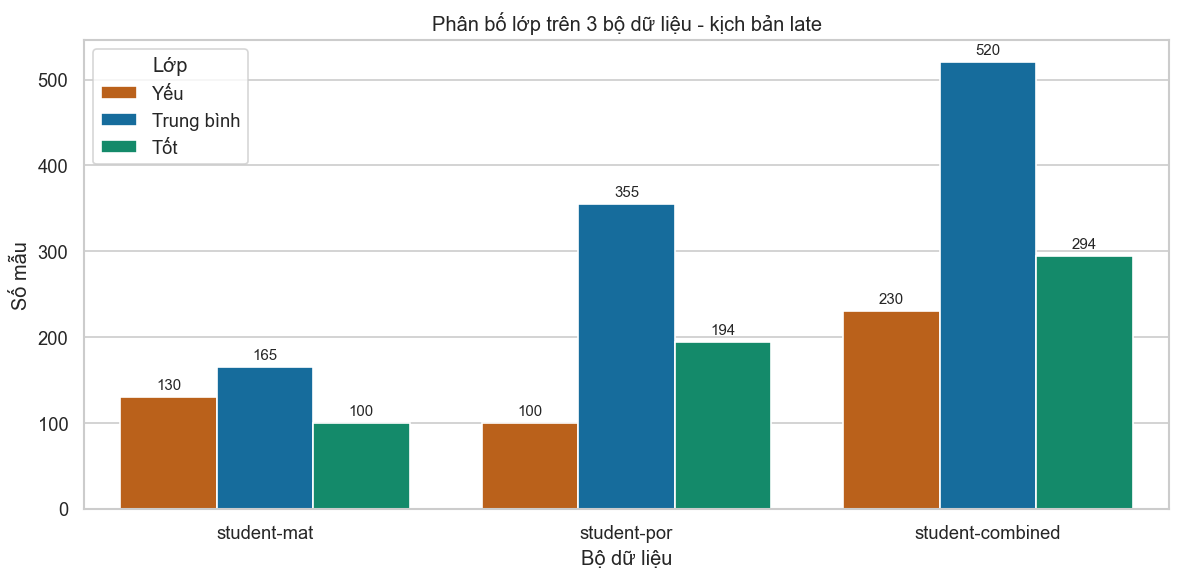

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
palette = ["#D55E00", "#0072B2", "#009E73"]

sns.barplot(
    data=distribution_df,
    x="dataset",
    y="count",
    hue="class_name",
    palette=palette,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

ax.set_title(f"Phân bố lớp trên 3 bộ dữ liệu - kịch bản {SCENARIO}")
ax.set_xlabel("Bộ dữ liệu")
ax.set_ylabel("Số mẫu")
ax.legend(title="Lớp")
plt.tight_layout()

count_figure_path = FIGURE_DIR / f"class_distribution_3_datasets_{SCENARIO}.png"
fig.savefig(count_figure_path, bbox_inches="tight")
count_figure_path

## Biểu đồ tỉ lệ phần trăm theo lớp

WindowsPath('c:/Huflit/kltn/reports/figures/class_percent_3_datasets_late.png')

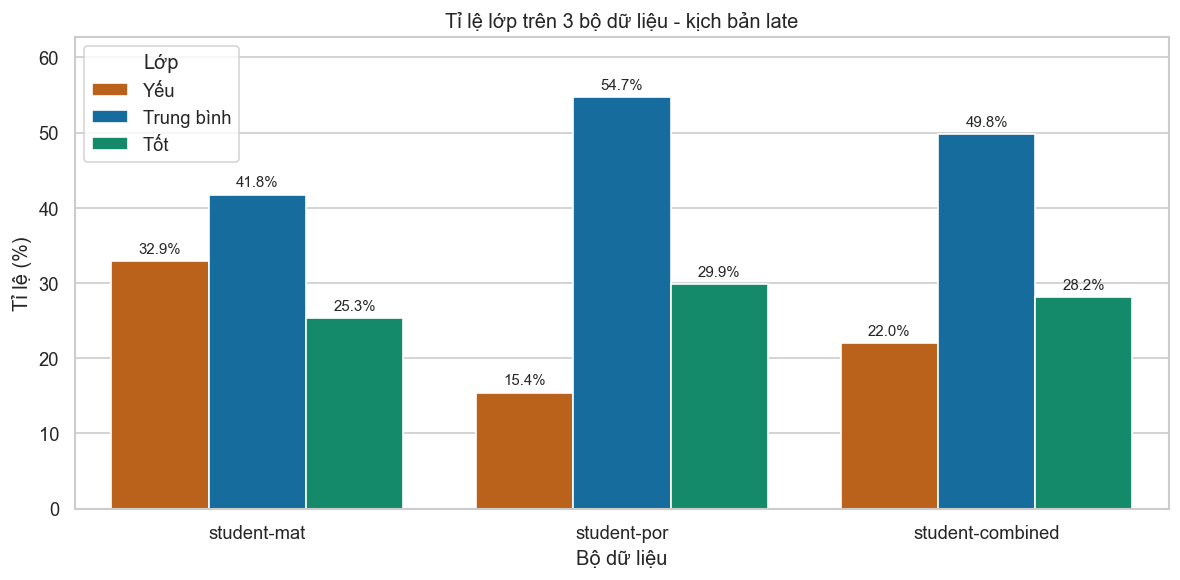

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=distribution_df,
    x="dataset",
    y="percent",
    hue="class_name",
    palette=palette,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

ax.set_title(f"Tỉ lệ lớp trên 3 bộ dữ liệu - kịch bản {SCENARIO}")
ax.set_xlabel("Bộ dữ liệu")
ax.set_ylabel("Tỉ lệ (%)")
ax.set_ylim(0, max(60, distribution_df["percent"].max() + 8))
ax.legend(title="Lớp")
plt.tight_layout()

percent_figure_path = FIGURE_DIR / f"class_percent_3_datasets_{SCENARIO}.png"
fig.savefig(percent_figure_path, bbox_inches="tight")
percent_figure_path

## Biểu đồ mức độ mất cân bằng

WindowsPath('c:/Huflit/kltn/reports/figures/imbalance_ratio_3_datasets_late.png')

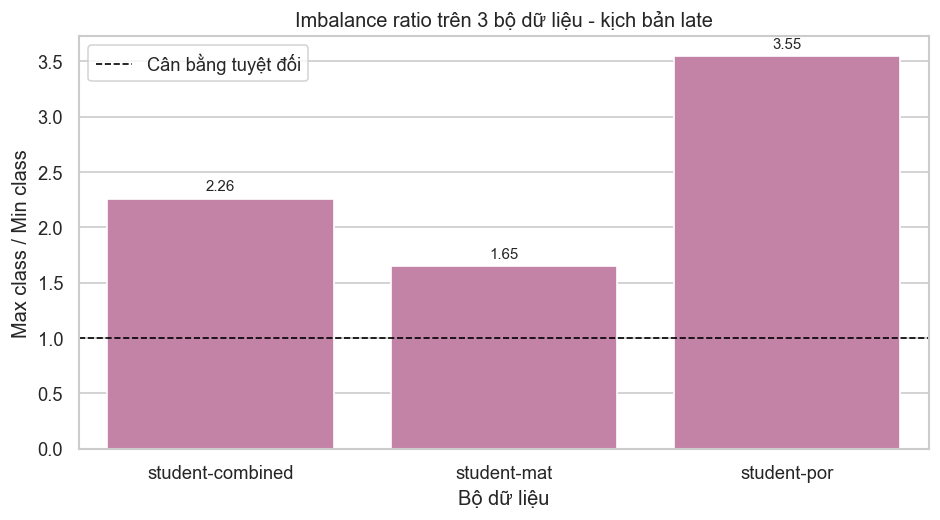

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.barplot(
    data=summary_df,
    x="dataset",
    y="imbalance_ratio",
    color="#CC79A7",
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

ax.axhline(1, color="black", linestyle="--", linewidth=1, label="Cân bằng tuyệt đối")
ax.set_title(f"Imbalance ratio trên 3 bộ dữ liệu - kịch bản {SCENARIO}")
ax.set_xlabel("Bộ dữ liệu")
ax.set_ylabel("Max class / Min class")
ax.legend()
plt.tight_layout()

ratio_figure_path = FIGURE_DIR / f"imbalance_ratio_3_datasets_{SCENARIO}.png"
fig.savefig(ratio_figure_path, bbox_inches="tight")
ratio_figure_path

## Kết luận ngắn

Nếu `imbalance_ratio` lớn hơn 1 và các cột phần trăm giữa các lớp chênh lệch rõ, dữ liệu đang mất cân bằng. Khi huấn luyện mô hình phân loại, nên so sánh baseline thường với các hướng xử lý mất cân bằng như `class_weight='balanced'`, RandomOverSampler, SMOTE, BorderlineSMOTE hoặc ADASYN.

In [ ]:
summary_df.to_csv(
    FIGURE_DIR / f"imbalance_summary_3_datasets_{SCENARIO}.csv",
    index=False,
    encoding="utf-8-sig",
)
print("Saved figures and summary table to:")
print(count_figure_path)
print(percent_figure_path)
print(ratio_figure_path)
print(FIGURE_DIR / f"imbalance_summary_3_datasets_{SCENARIO}.csv")